# Cross-task aggregate: reassigned neurons

Compare **reassigned neuron** counts (dead at some checkpoint, then `assigned` later) across experiments and optimizers. Data matches the *Reassigned neurons* section in `network_analysis.ipynb` / `network_analysis_classic_task.ipynb`.

In [1]:
import sys
from pathlib import Path

_PROJECT_ROOT = Path(".").resolve()
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from visualize_webapp.app import scan_results
from visualize_webapp.notebook.plot_cross_task import (
    load_reactivated_summaries_for_experiment_runs,
    load_summaries_for_experiment_runs,
    optimizer_ids_for_experiment_runs,
    plot_reactivated_neuron_counts_grouped,
    plot_reassigned_neuron_counts_grouped,
)

## Configuration


In [2]:
MODEL_ID = "dnn_5x64"
EXPERIMENT_RUNS = {
    "pretrain80_then_0_then_1_25_75": "529773",
    "pretrain_0_mislabel1_1_pt300_tr100": "66cd1c",
}

In [3]:
tree_all = scan_results()
for eid in EXPERIMENT_RUNS:
    models = tree_all.get(eid, {})
    for mid, runs in sorted(models.items()):
        for rid, oids in sorted(runs.items()):
            for oid in oids:
                mark = " *" if eid in EXPERIMENT_RUNS and rid == EXPERIMENT_RUNS[eid] else ""
                print(f"  experiment={eid!r}  model={mid!r}  run={rid!r}  optimizer={oid!r}{mark}")

  experiment='pretrain80_then_0_then_1_25_75'  model='dnn_5x64'  run='529773'  optimizer='sgd_lr0.01' *
  experiment='pretrain80_then_0_then_1_25_75'  model='dnn_5x64'  run='529773'  optimizer='adagrad_lr0.01' *
  experiment='pretrain80_then_0_then_1_25_75'  model='dnn_5x64'  run='529773'  optimizer='adam_lr0.01' *
  experiment='pretrain80_then_0_then_1_25_75'  model='dnn_5x64'  run='529773'  optimizer='pure_shampoo_lr0.01' *
  experiment='pretrain80_then_0_then_1_25_75'  model='dnn_5x64'  run='529773'  optimizer='grafted_shampoo_lr0.01' *
  experiment='pretrain_0_mislabel1_1_pt300_tr100'  model='dnn_5x64'  run='66cd1c'  optimizer='sgd_lr0.01' *
  experiment='pretrain_0_mislabel1_1_pt300_tr100'  model='dnn_5x64'  run='66cd1c'  optimizer='adagrad_lr0.01' *
  experiment='pretrain_0_mislabel1_1_pt300_tr100'  model='dnn_5x64'  run='66cd1c'  optimizer='adam_lr0.01' *
  experiment='pretrain_0_mislabel1_1_pt300_tr100'  model='dnn_5x64'  run='66cd1c'  optimizer='pure_shampoo_lr0.01' *
  experi

## Reassigned summary (MultiIndex)

Rows are indexed by `(experiment_id, optimizer_id)`; columns match `df_reassigned_summary` in the network analysis notebooks.

**Note:** Optimizers with **zero** reassigned neurons do not appear in `df_multi` at all (empty summaries add no rows when concatenated). Use `optimizer_ids_for_experiment_runs` for the full list from discovery; pass it as `optimizer_order` to the grouped bar plots so every optimizer gets a bar (height 0 when missing).

In [4]:
tree = scan_results()
OPTIMIZER_IDS = optimizer_ids_for_experiment_runs(tree, EXPERIMENT_RUNS, MODEL_ID)
df_multi = load_summaries_for_experiment_runs(tree, EXPERIMENT_RUNS, MODEL_ID)
print(df_multi.shape)
display(df_multi.head(20))

(11, 6)


compact  \
experiment_id                       optimizer_id                     
pretrain_0_mislabel1_1_pt300_tr100 sgd_lr0.01               h6:37   
                                    sgd_lr0.01               h6:57   
                                    sgd_lr0.01               h8:13   
                                    sgd_lr0.01               h8:60   
                                    sgd_lr0.01               h8:21   
                                    pure_shampoo_lr0.01      h6:19   
                                    pure_shampoo_lr0.01      h8:51   
                                    pure_shampoo_lr0.01      h8:11   
                                    pure_shampoo_lr0.01      h8:32   
                                    pure_shampoo_lr0.01       h8:0   
                                    grafted_shampoo_lr0.01   h4:38   

                                                                         neuron_id  \
experiment_id                       optimizer_id                                     
pretrain_0_mislabel1_1_pt300_tr100 sgd_lr0.01              dnn|hidden.6|neuron|37   
                                    sgd_lr0.01              dnn|hidden.6|neuron|57   
                                    sgd_lr0.01              dnn|hidden.8|neuron|13   
                                    sgd_lr0.01              dnn|hidden.8|neuron|60   
                                    sgd_lr0.01              dnn|hidden.8|neuron|21   
                                    pure_shampoo_lr0.01     dnn|hidden.6|neuron|19   
                                    pure_shampoo_lr0.01     dnn|hidden.8|neuron|51   
                                    pure_shampoo_lr0.01     dnn|hidden.8|neuron|11   
                                    pure_shampoo_lr0.01     dnn|hidden.8|neuron|32   
                                    pure_shampoo_lr0.01      dnn|hidden.8|neuron|0   
                                    grafted_shampoo_lr0.01  dnn|hidden.4|neuron|38   

                                                           layer_name  \
experiment_id                       optimizer_id                        
pretrain_0_mislabel1_1_pt300_tr100 sgd_lr0.01               hidden.6   
                                    sgd_lr0.01               hidden.6   
                                    sgd_lr0.01               hidden.8   
                                    sgd_lr0.01               hidden.8   
                                    sgd_lr0.01               hidden.8   
                                    pure_shampoo_lr0.01      hidden.6   
                                    pure_shampoo_lr0.01      hidden.8   
                                    pure_shampoo_lr0.01      hidden.8   
                                    pure_shampoo_lr0.01      hidden.8   
                                    pure_shampoo_lr0.01      hidden.8   
                                    grafted_shampoo_lr0.01   hidden.4   

                                                           first_reassign_checkpoint  \
experiment_id                       optimizer_id                                       
pretrain_0_mislabel1_1_pt300_tr100 sgd_lr0.01                                  3306   
                                    sgd_lr0.01                                  3408   
                                    sgd_lr0.01                                  3273   
                                    sgd_lr0.01                                  3273   
                                    sgd_lr0.01                                  3306   
                                    pure_shampoo_lr0.01                         3338   
                                    pure_shampoo_lr0.01                         3210   
                                    pure_shampoo_lr0.01                         3218   
                                    pure_shampoo_lr0.01                         3519   
                                    pure_shampoo_lr0.01                         3578   
                           

In [5]:
print("From discovery (all optimizers for selected runs):", OPTIMIZER_IDS)
print("In df_multi index only:", df_multi.index.unique("optimizer_id").tolist())

From discovery (all optimizers for selected runs): ['adagrad_lr0.01', 'adam_lr0.01', 'grafted_shampoo_lr0.01', 'pure_shampoo_lr0.01', 'sgd_lr0.01']
In df_multi index only: ['sgd_lr0.01', 'pure_shampoo_lr0.01', 'grafted_shampoo_lr0.01']


## Plot: reassigned neuron counts

X-axis = optimizer; grouped bars = one bar per experiment; Y = number of reassigned neurons (unique neurons dead then later assigned).

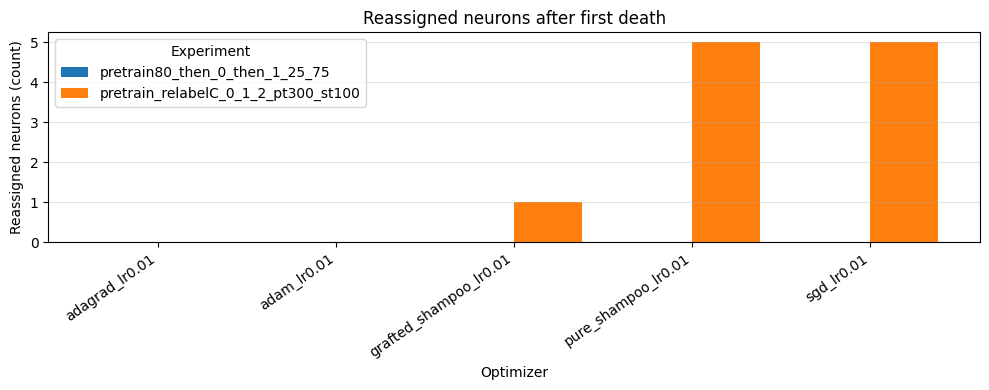

In [6]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=100)
plot_reassigned_neuron_counts_grouped(
    df_multi,
    ax=ax,
    experiment_order=list(EXPERIMENT_RUNS.keys()),
    optimizer_order=OPTIMIZER_IDS,
)
fig.tight_layout()
plt.show()

## Re-activated summary

One row per neuron with at least one dead→alive step between neighbouring checkpoints (hidden layers). Index: `(experiment_id, optimizer_id)`.

In [7]:
df_reactivated_multi = load_reactivated_summaries_for_experiment_runs(
    tree, EXPERIMENT_RUNS, MODEL_ID
)
print(df_reactivated_multi.shape)
display(df_reactivated_multi.head(20))

(109, 4)


compact  \
experiment_id                       optimizer_id                     
pretrain80_then_0_then_1_25_75      sgd_lr0.01                h2:1   
                                    sgd_lr0.01               h4:50   
                                    sgd_lr0.01                h4:1   
                                    sgd_lr0.01               h6:19   
                                    adagrad_lr0.01           h2:53   
                                    adagrad_lr0.01           h6:12   
                                    adagrad_lr0.01           h6:20   
                                    adagrad_lr0.01           h6:37   
                                    adagrad_lr0.01           h8:24   
                                    pure_shampoo_lr0.01       h4:8   
                                    pure_shampoo_lr0.01      h4:25   
                                    pure_shampoo_lr0.01      h8:19   
                                    pure_shampoo_lr0.01      h8:59   
                                    grafted_shampoo_lr0.01    h6:4   
                                    grafted_shampoo_lr0.01   h8:36   
pretrain_0_mislabel1_1_pt300_tr100 sgd_lr0.01               h2:63   
                                    sgd_lr0.01               h2:48   
                                    sgd_lr0.01               h2:31   
                                    sgd_lr0.01               h2:10   
                                    sgd_lr0.01               h4:17   

                                                                         neuron_id  \
experiment_id                       optimizer_id                                     
pretrain80_then_0_then_1_25_75      sgd_lr0.01               dnn|hidden.2|neuron|1   
                                    sgd_lr0.01              dnn|hidden.4|neuron|50   
                                    sgd_lr0.01               dnn|hidden.4|neuron|1   
                                    sgd_lr0.01              dnn|hidden.6|neuron|19   
                                    adagrad_lr0.01          dnn|hidden.2|neuron|53   
                                    adagrad_lr0.01          dnn|hidden.6|neuron|12   
                                    adagrad_lr0.01          dnn|hidden.6|neuron|20   
                                    adagrad_lr0.01          dnn|hidden.6|neuron|37   
                                    adagrad_lr0.01          dnn|hidden.8|neuron|24   
                                    pure_shampoo_lr0.01      dnn|hidden.4|neuron|8   
                                    pure_shampoo_lr0.01     dnn|hidden.4|neuron|25   
                                    pure_shampoo_lr0.01     dnn|hidden.8|neuron|19   
                                    pure_shampoo_lr0.01     dnn|hidden.8|neuron|59   
                                    grafted_shampoo_lr0.01   dnn|hidden.6|neuron|4   
                                    grafted_shampoo_lr0.01  dnn|hidden.8|neuron|36   
pretrain_0_mislabel1_1_pt300_tr100 sgd_lr0.01              dnn|hidden.2|neuron|63   
                                    sgd_lr0.01              dnn|hidden.2|neuron|48   
                                    sgd_lr0.01              dnn|hidden.2|neuron|31   
                                    sgd_lr0.01              dnn|hidden.2|neuron|10   
                                    sgd_lr0.01              dnn|hidden.4|neuron|17   

                                                           layer_name  \
experiment_id                       optimizer_id                        
pretrain80_then_0_then_1_25_75      sgd_lr0.01               hidden.2   
                                    sgd_lr0.01               hidden.4   
                                    sgd_lr0.01               hidden.4   
                                    sgd_lr0.01               hidden.6   
                                    adagrad_lr0.01           hidden.2   
                                    adagrad_lr0.01           hidden.6   
                                    adagrad

## Plot: re-activated neuron counts

Same layout as above: x = optimizer, grouped bars = experiments, y = count of re-activated (recovered-at-least-once) hidden neurons.

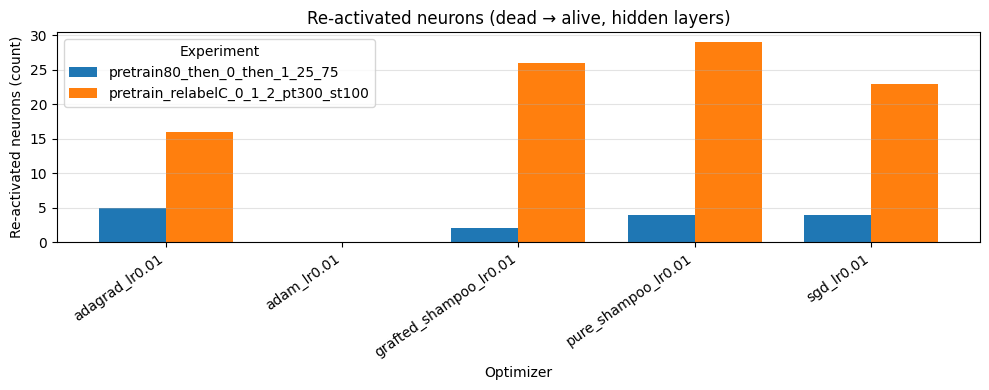

In [8]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=100)
plot_reactivated_neuron_counts_grouped(
    df_reactivated_multi,
    ax=ax,
    experiment_order=list(EXPERIMENT_RUNS.keys()),
    optimizer_order=OPTIMIZER_IDS,
)
fig.tight_layout()
plt.show()